# Customer personality analysis

Une épicerie de quartier souhaite mieux connaître ses clients pour arrêter de communiquer de la même façon auprès de tout le monde. L'objectif de ce notebook est de construire une segmentation de sa clientèle par apprentissage non supervisé (clustering), afin de faire ressortir des groupes de clients cohérents et de dresser le profil de chacun.

Avant de s'attaquer aux données réelles de l'épicerie, la **Partie 1** sert de galop d'essai sur le dataset **Iris**, dont les 3 classes sont connues à l'avance : c'est l'occasion de coder notre propre implémentation de K-Means "from scratch" (voir `kmeans.py`), de la comparer à celle de scikit-learn, et de vérifier que le clustering obtenu retrouve à peu près la vraie structure du dataset.

La **Partie 2** applique la même démarche, cette fois sans vérité terrain, aux données de l'épicerie : exploration, nettoyage, feature engineering, réduction de dimension, puis comparaison de plusieurs algorithmes de clustering pour aboutir à un profiling actionnable des segments de clients.


# Partie 1 - Dataset Iris

In [1]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

iris = load_iris(as_frame=True)
print(iris.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


## Nettoyage du dataset (doublons, valeurs aberrantes, etc.)

In [2]:
db = iris.frame

print(f"Dimensions du dataset brut : {db.shape}")

# Suppression des doublons
n_before = len(db)
db = db.drop_duplicates()
print(f"Doublons supprimés : {n_before - len(db)}")

# Vérification des valeurs manquantes
print("\nValeurs manquantes par colonne :")
print(db.isnull().sum())

print("\nAperçu des premières lignes :")
print(db.head())

Dimensions du dataset brut : (150, 5)
Doublons supprimés : 1

Valeurs manquantes par colonne :
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

Aperçu des premières lignes :
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


## Pré-traitement des données (normalisation, encodage, etc.)

In [3]:
from sklearn.preprocessing import StandardScaler

# Séparation variables / cible
features = [col for col in db.columns if col != "target"]
X = db[features]

# Standardisation (moyenne=0, écart-type=1), requis pour K-Means (distance euclidienne sensible aux échelles)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features, index=X.index)

print("Statistiques AVANT normalisation :")
print(X.describe().round(2))
print("\nStatistiques APRÈS normalisation :")
print(X_scaled.describe().round(2))

Statistiques AVANT normalisation :
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count             149.00            149.00             149.00   
mean                5.84              3.06               3.75   
std                 0.83              0.44               1.77   
min                 4.30              2.00               1.00   
25%                 5.10              2.80               1.60   
50%                 5.80              3.00               4.30   
75%                 6.40              3.30               5.10   
max                 7.90              4.40               6.90   

       petal width (cm)  
count            149.00  
mean               1.19  
std                0.76  
min                0.10  
25%                0.30  
50%                1.30  
75%                1.80  
max                2.50  

Statistiques APRÈS normalisation :
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count             149.00            149.00  

## Analyse descriptive et exploratoire générale des données

In [4]:
print("=== Statistiques descriptives ===")
print(db.describe().round(2))
print(f"\nDistribution des classes (0=setosa, 1=versicolor, 2=virginica) :")
print(db["target"].value_counts().sort_index())

=== Statistiques descriptives ===
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count             149.00            149.00             149.00   
mean                5.84              3.06               3.75   
std                 0.83              0.44               1.77   
min                 4.30              2.00               1.00   
25%                 5.10              2.80               1.60   
50%                 5.80              3.00               4.30   
75%                 6.40              3.30               5.10   
max                 7.90              4.40               6.90   

       petal width (cm)  target  
count            149.00  149.00  
mean               1.19    0.99  
std                0.76    0.82  
min                0.10    0.00  
25%                0.30    0.00  
50%                1.30    1.00  
75%                1.80    2.00  
max                2.50    2.00  

Distribution des classes (0=setosa, 1=versicolor, 2=virginica) :
target
0

### Distribution des variables

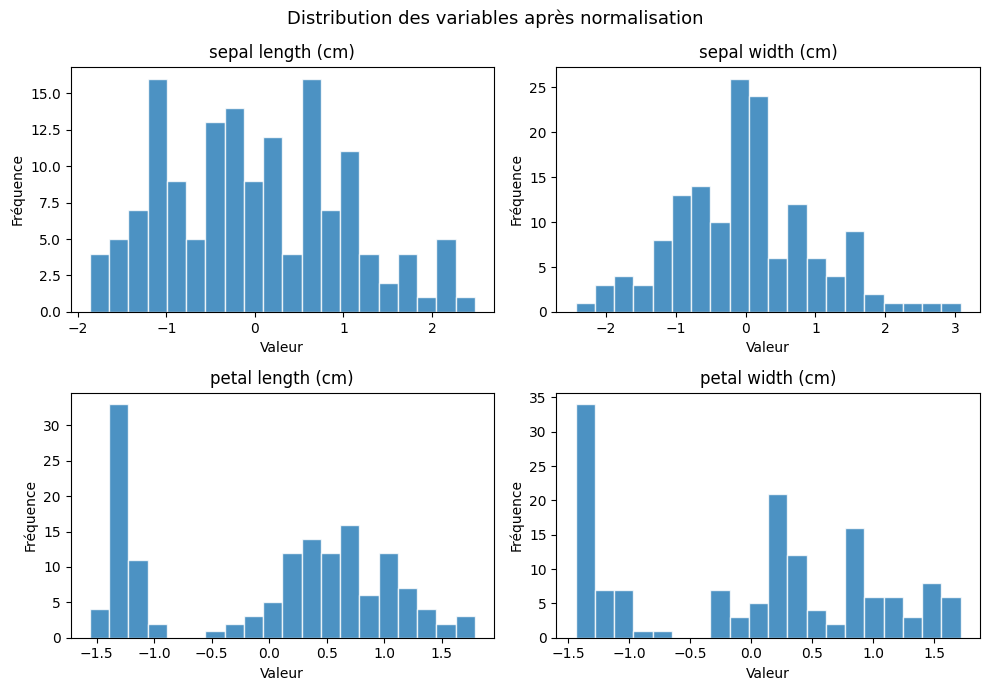

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(X_scaled[col], bins=20, edgecolor="white", alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel("Valeur")
    axes[i].set_ylabel("Fréquence")

plt.suptitle("Distribution des variables après normalisation", fontsize=13)
plt.tight_layout()
plt.show()

### Matrice de corrélation des variables

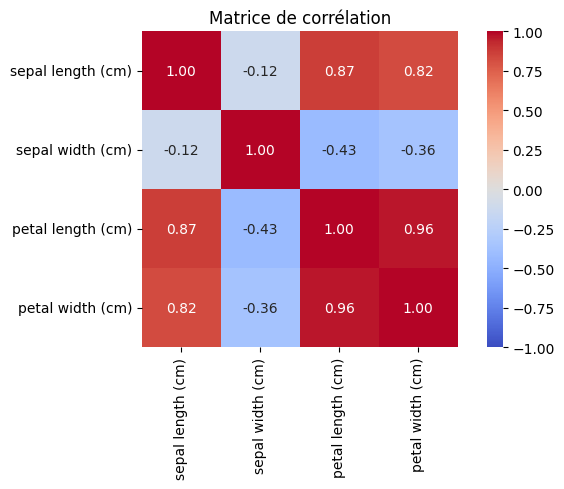

In [6]:
corr = X.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

### Pairplot : relations entre variables par espèce

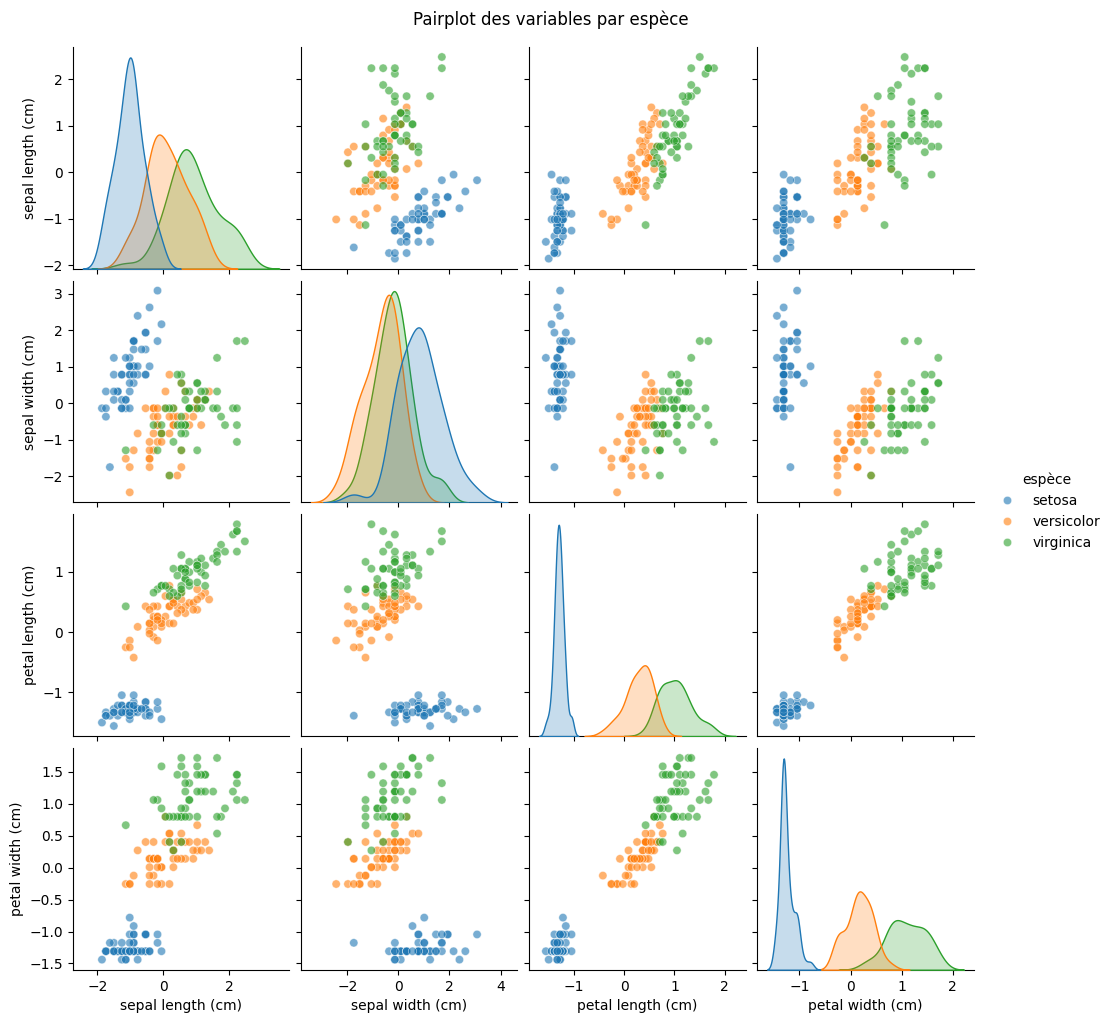

In [7]:
species_names = {0: "setosa", 1: "versicolor", 2: "virginica"}
plot_df = X_scaled.copy()
plot_df["espèce"] = db["target"].map(species_names)

sns.pairplot(plot_df, hue="espèce", diag_kind="kde", plot_kws={"alpha": 0.6})
plt.suptitle("Pairplot des variables par espèce", y=1.02)
plt.show()

## Test avec fonction K-Means de la bibliothèque scikit-learn

Inertie : 138.77

Distribution des clusters :
cluster
0    52
1    50
2    47
Name: count, dtype: int64


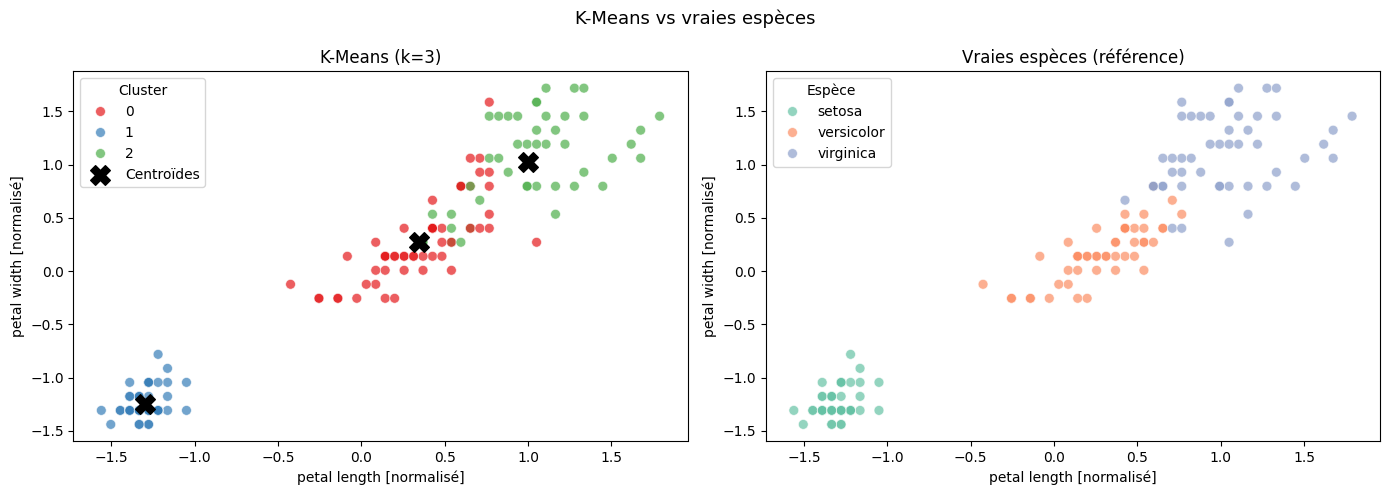


Crosstab clusters vs espèces :
espèce   setosa  versicolor  virginica
cluster                               
0             0          39         13
1            50           0          0
2             0          11         36


In [8]:
from sklearn.cluster import KMeans

k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(X_scaled)
labels = kmeans.labels_
centers = kmeans.cluster_centers_

print(f"Inertie : {kmeans.inertia_:.2f}")
print(f"\nDistribution des clusters :")
print(pd.Series(labels, name="cluster").value_counts().sort_index())

# Visualisation clusters vs espèces réelles
petal_l_idx = features.index("petal length (cm)")
petal_w_idx = features.index("petal width (cm)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(ax=axes[0], x=X_scaled["petal length (cm)"], y=X_scaled["petal width (cm)"],
                hue=labels, palette="Set1", alpha=0.7, s=50)
axes[0].scatter(centers[:, petal_l_idx], centers[:, petal_w_idx],
                marker="X", s=200, c="black", zorder=5, label="Centroïdes")
axes[0].set_title(f"K-Means (k={k})")
axes[0].set_xlabel("petal length [normalisé]")
axes[0].set_ylabel("petal width [normalisé]")
axes[0].legend(title="Cluster")

species_map = {0: "setosa", 1: "versicolor", 2: "virginica"}
sns.scatterplot(ax=axes[1], x=X_scaled["petal length (cm)"], y=X_scaled["petal width (cm)"],
                hue=db["target"].map(species_map), palette="Set2", alpha=0.7, s=50)
axes[1].set_title("Vraies espèces (référence)")
axes[1].set_xlabel("petal length [normalisé]")
axes[1].set_ylabel("petal width [normalisé]")
axes[1].legend(title="Espèce")

plt.suptitle("K-Means vs vraies espèces", fontsize=13)
plt.tight_layout()
plt.show()

print("\nCrosstab clusters vs espèces :")
print(pd.crosstab(labels, db["target"].map(species_map), rownames=["cluster"], colnames=["espèce"]))

## Application de notre implémentation K-Means "from scratch"

La classe `KMeans` codée dans `kmeans.py` (algorithme de Lloyd, initialisation k-means++, plusieurs essais gardés selon l'inertie) est appliquée ici aux mêmes données, pour vérifier qu'elle retombe bien sur des résultats équivalents à ceux de scikit-learn.

In [9]:
from kmeans import KMeans as KMeansMaison

kmeans_maison = KMeansMaison(n_clusters=k, init="k-means++", n_init=10, random_state=42)
labels_maison = kmeans_maison.fit_predict(X_scaled.values)

print(f"Inertie (implémentation maison) : {kmeans_maison.inertia_:.2f}")
print(f"Inertie (scikit-learn)          : {kmeans.inertia_:.2f}")

print("\nCrosstab clusters (implémentation maison) vs espèces :")
print(pd.crosstab(labels_maison, db["target"].map(species_map), rownames=["cluster"], colnames=["espèce"]))

Inertie (implémentation maison) : 138.77
Inertie (scikit-learn)          : 138.77

Crosstab clusters (implémentation maison) vs espèces :
espèce   setosa  versicolor  virginica
cluster                               
0            50           0          0
1             0          11         36
2             0          39         13


### Stabilité selon l'initialisation (plusieurs lancements de notre implémentation)

Toujours avec notre implémentation, on relance le clustering plusieurs fois avec un seul essai à chaque fois (`n_init=1`), en comparant une initialisation purement aléatoire à k-means++.

In [10]:
print("seed | inertie (init random) | inertie (init k-means++)")
for seed in range(5):
    m_random = KMeansMaison(n_clusters=k, init="random", n_init=1, random_state=seed)
    m_random.fit(X_scaled.values)

    m_plusplus = KMeansMaison(n_clusters=k, init="k-means++", n_init=1, random_state=seed)
    m_plusplus.fit(X_scaled.values)

    print(f"{seed:4d} | {m_random.inertia_:22.2f} | {m_plusplus.inertia_:24.2f}")

seed | inertie (init random) | inertie (init k-means++)
   0 |                 139.04 |                   138.78
   1 |                 138.78 |                   139.04
   2 |                 189.88 |                   196.19
   3 |                 189.70 |                   138.77
   4 |                 139.57 |                   139.57


### Remarques après plusieurs lancement du K-means avec plusieurs valeurs de k différentes.

On observe que pour k=3, le cluster 0 correspond exactement aux 50 individus *setosa* (aucune erreur) : cette espèce est linéairement séparable des deux autres sur les variables de pétale/sépale normalisées. En revanche, les clusters 1 et 2 mélangent *versicolor* et *virginica* (respectivement 11 vs 36, puis 39 vs 13 individus) : ces deux espèces se chevauchent dans l'espace des variables, donc K-Means (qui ignore les vraies étiquettes) trace une frontière légèrement différente de la frontière biologique réelle.

Notre implémentation "from scratch" retombe exactement sur le même résultat que scikit-learn (inertie de 138.77 dans les deux cas, mêmes clusters) : elle valide bien l'algorithme de Lloyd et l'initialisation k-means++.

En revanche, quand on la relance avec un seul essai (n_init=1) et différentes graines aléatoires, on voit apparaître de l'instabilité : la plupart des graines retombent sur la même inertie (~138.8-139.6), mais certaines (ex. seed=2) restent bloquées dans un optimum local nettement moins bon (inertie ~190-196), aussi bien avec une initialisation aléatoire qu'avec k-means++. C'est exactement pour ça que scikit-learn (et notre classe) relance plusieurs fois par défaut (`n_init=10`) et ne garde que le meilleur résultat : un seul lancement ne suffit pas à garantir un bon minimum.

En relançant l'algorithme avec k allant de 2 à 6 :
- k=2 fusionne *versicolor* et *virginica* en un seul cluster ; l'inertie est la plus élevée mais le score de silhouette est le meilleur (~0.58), car les 2 groupes obtenus sont très compacts et bien séparés.
- k=3 correspond à la structure biologique attendue (silhouette ~0.46).
- au-delà de k=3, l'inertie continue de baisser mais de façon de plus en plus modérée (rendement décroissant, cf. coude à k=3) et le score de silhouette chute (~0.38 à k=4, ~0.34 à k=5-6) : K-Means se contente alors de fragmenter artificiellement le groupe versicolor/virginica sans que cela corresponde à une vraie sous-structure des données.

k=3 reste donc le choix le plus pertinent d'un point de vue métier (nombre d'espèces connu), même si le score de silhouette seul suggérerait k=2.

## Evaluation du nombre optimal de clusters et évaluation de la qualité de ceux-ci

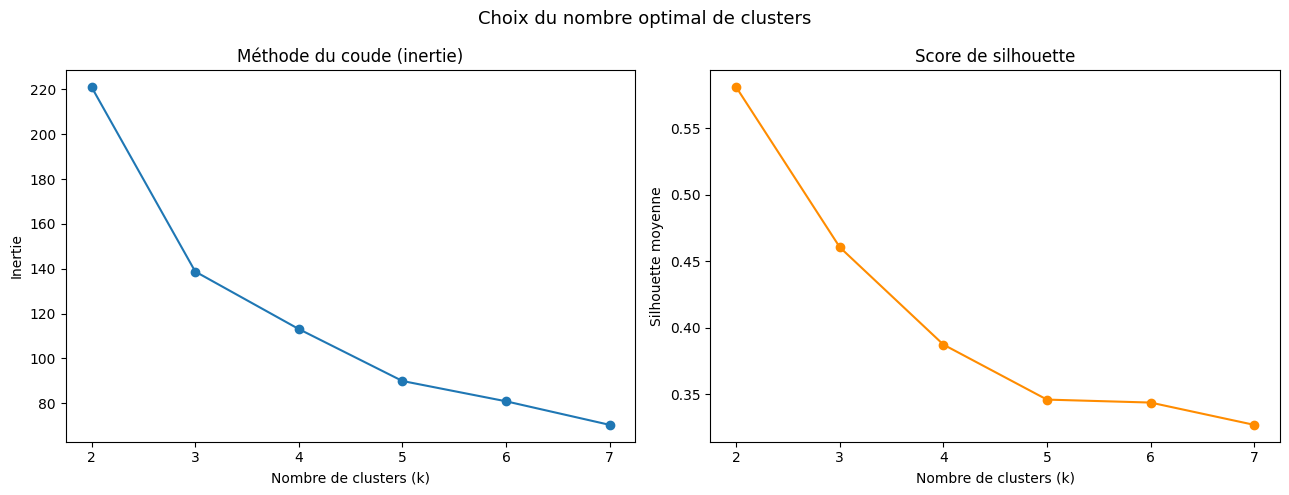

Meilleur k selon le score de silhouette : 2
k=2 : inertie=221.01, silhouette=0.581
k=3 : inertie=138.77, silhouette=0.461
k=4 : inertie=113.12, silhouette=0.388
k=5 : inertie=89.95, silhouette=0.346
k=6 : inertie=80.90, silhouette=0.344
k=7 : inertie=70.39, silhouette=0.327


In [11]:
from sklearn.metrics import silhouette_score

k_range = range(2, 8)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Méthode du coude (inertie)")
axes[0].set_xlabel("Nombre de clusters (k)")
axes[0].set_ylabel("Inertie")

axes[1].plot(list(k_range), silhouettes, marker="o", color="darkorange")
axes[1].set_title("Score de silhouette")
axes[1].set_xlabel("Nombre de clusters (k)")
axes[1].set_ylabel("Silhouette moyenne")

plt.suptitle("Choix du nombre optimal de clusters", fontsize=13)
plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(silhouettes))]
print(f"Meilleur k selon le score de silhouette : {best_k}")
for k, i, s in zip(k_range, inertias, silhouettes):
    print(f"k={k} : inertie={i:.2f}, silhouette={s:.3f}")

# Partie 2 - Dataset Epicerie 

In [12]:
df_epicerie = pd.read_csv("data/raw/marketing_campaign.csv", sep="\t")

print(f"Dimensions du dataset brut : {df_epicerie.shape}")
print("\nTypes de colonnes :")
print(df_epicerie.dtypes)
print("\nAperçu des premières lignes :")
df_epicerie.head()

Dimensions du dataset brut : (2240, 29)

Types de colonnes :
ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

Aperçu des premières lign

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## Nettoyage du dataset (doublons, valeurs aberrantes, etc.)

In [13]:
db_epi = df_epicerie.copy()

print(f"Dimensions du dataset brut : {db_epi.shape}")

# Suppression des doublons
n_before = len(db_epi)
db_epi = db_epi.drop_duplicates()
print(f"Doublons supprimés : {n_before - len(db_epi)}")

# Valeurs manquantes
print("\nValeurs manquantes par colonne :")
print(db_epi.isnull().sum()[db_epi.isnull().sum() > 0])

# Income manquant (24 lignes sur 2240, négligeable) -> suppression des lignes
db_epi = db_epi.dropna(subset=["Income"])

# Catégories aberrantes dans Marital_Status
print("\nCatégories de Marital_Status :")
print(db_epi["Marital_Status"].value_counts())
db_epi = db_epi[~db_epi["Marital_Status"].isin(["Absurd", "YOLO"])]

# Valeurs aberrantes : année de naissance irréaliste et revenu extrême
n_birth_outliers = (db_epi["Year_Birth"] < 1930).sum()
n_income_outliers = (db_epi["Income"] > 200000).sum()
print(f"\nClients nés avant 1930 : {n_birth_outliers}")
print(f"Clients avec un revenu > 200 000 : {n_income_outliers}")

db_epi = db_epi[(db_epi["Year_Birth"] >= 1930) & (db_epi["Income"] <= 200000)]

print(f"\nDimensions après nettoyage : {db_epi.shape}")
print("\nAperçu des premières lignes :")
db_epi.head()

Dimensions du dataset brut : (2240, 29)
Doublons supprimés : 0

Valeurs manquantes par colonne :
Income    24
dtype: int64

Catégories de Marital_Status :
Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

Clients nés avant 1930 : 3
Clients avec un revenu > 200 000 : 1

Dimensions après nettoyage : (2208, 29)

Aperçu des premières lignes :


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## Analyse descriptive et exploratoire générale des données

=== Statistiques descriptives ===
            ID  Year_Birth    Income  Kidhome  Teenhome  Recency  MntWines  \
count   2208.0      2208.0    2208.0   2208.0    2208.0   2208.0    2208.0   
mean    5584.5      1968.9   51943.5      0.4       0.5     49.1     305.2   
std     3246.1        11.7   21536.8      0.5       0.5     28.9     337.6   
min        0.0      1940.0    1730.0      0.0       0.0      0.0       0.0   
25%     2814.8      1959.0   35196.0      0.0       0.0     24.0      24.0   
50%     5454.5      1970.0   51371.0      0.0       0.0     49.0     174.0   
75%     8418.5      1977.0   68487.0      1.0       1.0     74.0     505.5   
max    11191.0      1996.0  162397.0      2.0       2.0     99.0    1493.0   

       MntFruits  MntMeatProducts  MntFishProducts  ...  NumWebVisitsMonth  \
count     2208.0           2208.0           2208.0  ...             2208.0   
mean        26.3            167.0             37.5  ...                5.3   
std         39.7            2

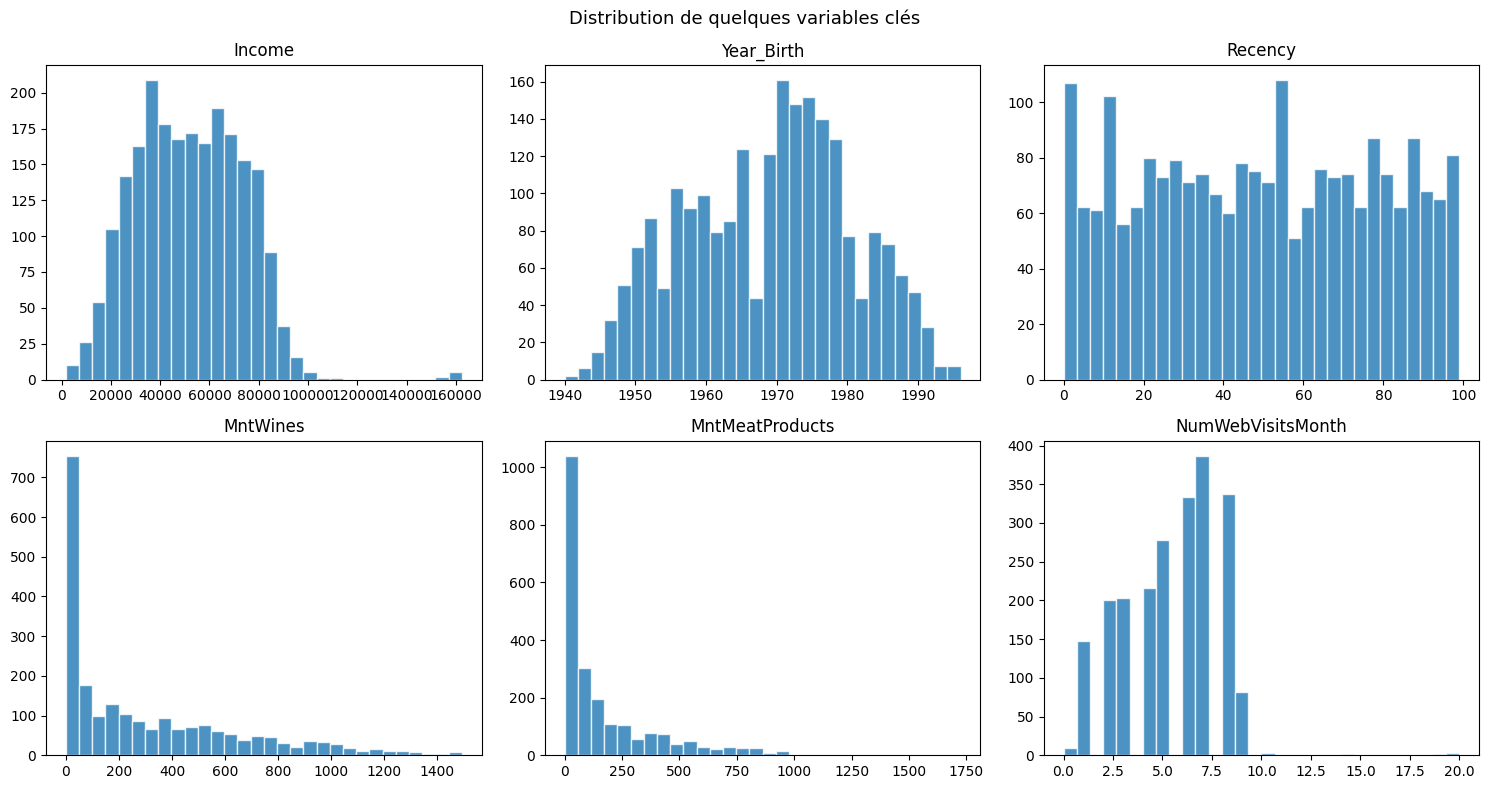

In [14]:
print("=== Statistiques descriptives ===")
print(db_epi.describe().round(1))

print("\n=== Répartition Education ===")
print(db_epi["Education"].value_counts())

print("\n=== Répartition Marital_Status ===")
print(db_epi["Marital_Status"].value_counts())

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
dist_cols = ["Income", "Year_Birth", "Recency", "MntWines", "MntMeatProducts", "NumWebVisitsMonth"]
for i, col in enumerate(dist_cols):
    axes[i].hist(db_epi[col], bins=30, edgecolor="white", alpha=0.8)
    axes[i].set_title(col)

plt.suptitle("Distribution de quelques variables clés", fontsize=13)
plt.tight_layout()
plt.show()

### Matrice de corrélation des variables numériques

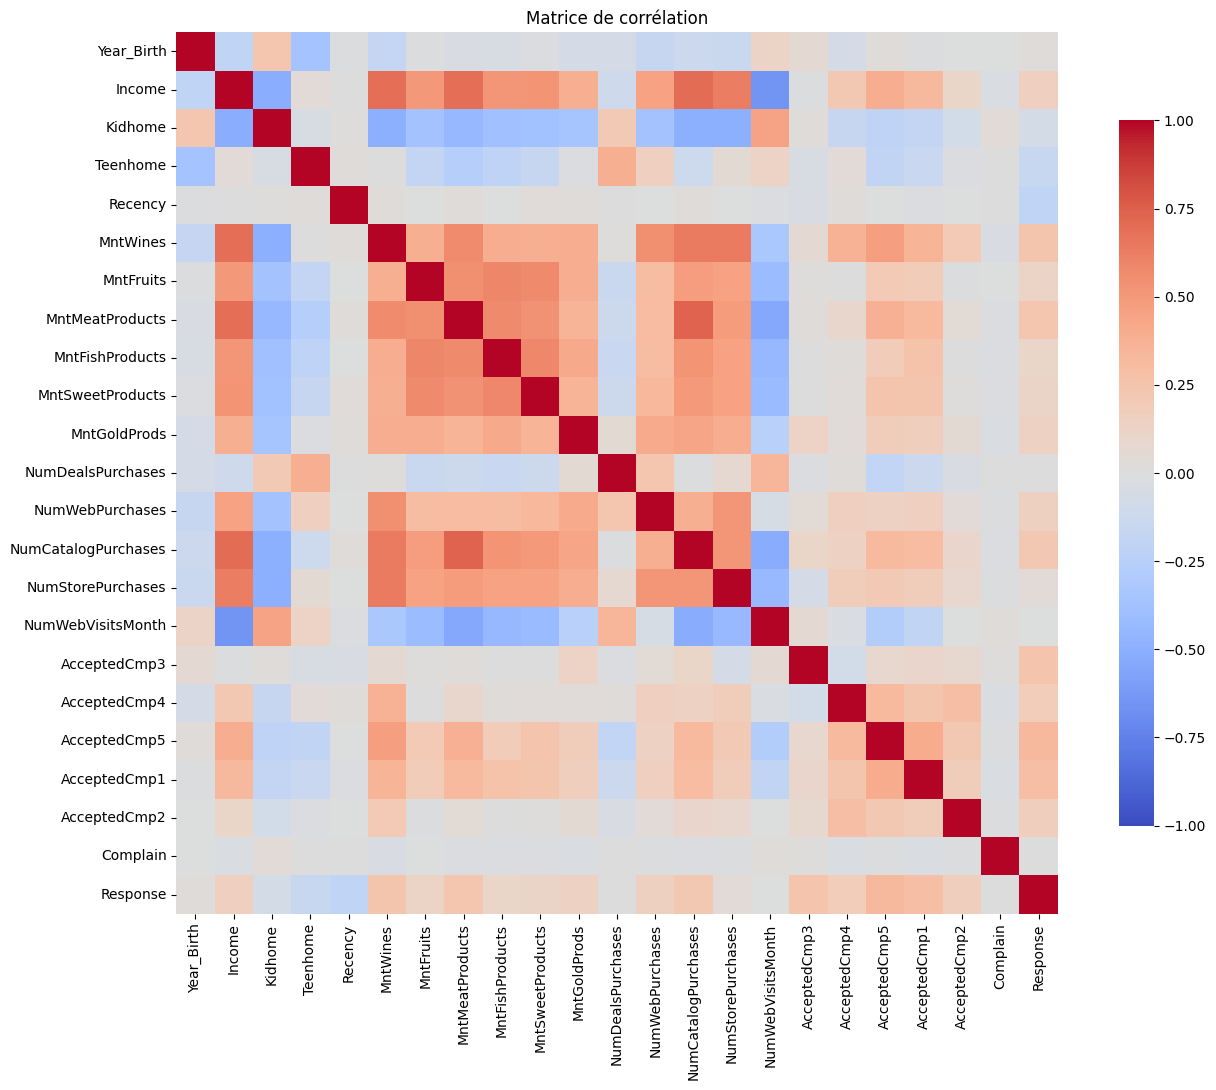

In [15]:
num_cols = db_epi.select_dtypes(include=[np.number]).drop(columns=["ID", "Z_CostContact", "Z_Revenue"])
corr = num_cols.corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap="coolwarm", vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.8})
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

## Pré-traitement des données (feature engineering, encodage, normalisation)

In [16]:
# Age et ancienneté client (relatifs à la date d'inscription la plus récente du dataset)
db_epi["Dt_Customer"] = pd.to_datetime(db_epi["Dt_Customer"], format="%d-%m-%Y")
ref_date = db_epi["Dt_Customer"].max() + pd.Timedelta(days=1)
db_epi["Age"] = ref_date.year - db_epi["Year_Birth"]
db_epi["Customer_For"] = (ref_date - db_epi["Dt_Customer"]).dt.days

# Agrégation des dépenses et achats par canal (fortement corrélés entre eux, cf. matrice de corrélation)
mnt_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
db_epi["Total_Spending"] = db_epi[mnt_cols].sum(axis=1)

purchase_cols = ["NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]
db_epi["Total_Purchases"] = db_epi[purchase_cols].sum(axis=1)

cmp_cols = ["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response"]
db_epi["Total_AcceptedCmp"] = db_epi[cmp_cols].sum(axis=1)

# Nombre total d'enfants au foyer
db_epi["Children"] = db_epi["Kidhome"] + db_epi["Teenhome"]

# Simplification des catégories (regroupement des modalités rares/proches)
db_epi["Education"] = db_epi["Education"].replace({
    "Basic": "Undergraduate", "2n Cycle": "Undergraduate",
    "Graduation": "Graduate", "Master": "Postgraduate", "PhD": "Postgraduate",
})
db_epi["Marital_Status"] = db_epi["Marital_Status"].replace({
    "Married": "Partner", "Together": "Partner",
    "Single": "Single", "Divorced": "Single", "Widow": "Single", "Alone": "Single",
})

# Suppression des colonnes désormais inutiles (identifiant, redondantes, constantes)
db_epi = db_epi.drop(columns=["ID", "Year_Birth", "Dt_Customer", "Z_CostContact", "Z_Revenue"])

print(f"Dimensions après feature engineering : {db_epi.shape}")
db_epi[["Age", "Customer_For", "Total_Spending", "Total_Purchases", "Children", "Total_AcceptedCmp"]].describe().round(1)

Dimensions après feature engineering : (2208, 30)


,Age,Customer_For,Total_Spending,Total_Purchases,Children,Total_AcceptedCmp
count,2208.0,2208.0,2208.0,2208.0,2208.0,2208.0
mean,45.1,354.5,606.9,14.9,0.9,0.4
std,11.7,202.4,602.8,7.7,0.7,0.9
min,18.0,1.0,5.0,0.0,0.0,0.0
25%,37.0,181.0,69.0,8.0,0.0,0.0
50%,44.0,356.5,396.0,15.0,1.0,0.0
75%,55.0,530.0,1047.2,21.0,1.0,1.0
max,74.0,700.0,2525.0,44.0,3.0,5.0


In [17]:
# Encodage des variables catégorielles (one-hot, en gardant une modalité de référence)
db_encoded = pd.get_dummies(db_epi, columns=["Education", "Marital_Status"], drop_first=True)

# Standardisation de toutes les variables (requis pour PCA et K-Means/GMM, sensibles aux échelles)
epi_scaler = StandardScaler()
X_epi_scaled = pd.DataFrame(
    epi_scaler.fit_transform(db_encoded),
    columns=db_encoded.columns,
    index=db_encoded.index,
)

print(f"Dimensions après encodage : {X_epi_scaled.shape}")
X_epi_scaled.describe().round(2)

Dimensions après encodage : (2208, 31)


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Response,Age,Customer_For,Total_Spending,Total_Purchases,Total_AcceptedCmp,Children,Education_Postgraduate,Education_Undergraduate,Marital_Status_Single
count,2208.00,2208.00,2208.00,2208.00,2208.00,2208.00,2208.00,2208.00,2208.00,2208.00,...,2208.00,2208.00,2208.00,2208.00,2208.00,2208.00,2208.00,2208.00,2208.00,2208.00
mean,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.33,-0.82,-0.93,-1.70,-0.90,-0.66,-0.74,-0.69,-0.66,-0.85,...,-0.42,-2.32,-1.75,-1.00,-1.94,-0.50,-1.27,-0.79,-0.36,-0.74
25%,-0.78,-0.82,-0.93,-0.87,-0.83,-0.62,-0.67,-0.63,-0.63,-0.68,...,-0.42,-0.69,-0.86,-0.89,-0.90,-0.50,-1.27,-0.79,-0.36,-0.74
50%,-0.03,-0.82,-0.93,-0.00,-0.39,-0.46,-0.44,-0.47,-0.46,-0.38,...,-0.42,-0.09,0.01,-0.35,0.02,-0.50,0.07,-0.79,-0.36,-0.74
75%,0.77,1.04,0.91,0.86,0.59,0.17,0.29,0.23,0.14,0.24,...,-0.42,0.85,0.87,0.73,0.80,0.62,0.07,1.27,-0.36,1.35
max,5.13,2.90,2.75,1.73,3.52,4.35,6.95,4.06,5.72,5.38,...,2.38,2.47,1.71,3.18,3.79,5.10,2.74,1.27,2.79,1.35


## Réduction de dimension (sélection de features et PCA)

In [18]:
# Sélection de features : on retire les colonnes détaillées désormais capturées par les agrégats
# (Mnt*, Num*Purchases, AcceptedCmp*, Kidhome/Teenhome), fortement corrélées entre elles (cf. matrice de corrélation)
redundant_cols = mnt_cols + purchase_cols + cmp_cols + ["Kidhome", "Teenhome"]
X_model = X_epi_scaled.drop(columns=redundant_cols)

print(f"Colonnes retenues pour le clustering ({X_model.shape[1]}) :")
print(list(X_model.columns))

Colonnes retenues pour le clustering (13) :
['Income', 'Recency', 'NumWebVisitsMonth', 'Complain', 'Age', 'Customer_For', 'Total_Spending', 'Total_Purchases', 'Total_AcceptedCmp', 'Children', 'Education_Postgraduate', 'Education_Undergraduate', 'Marital_Status_Single']


Variance expliquée par composante : [0.26  0.112 0.099]
Variance totale expliquée par les 3 composantes : 47.1%


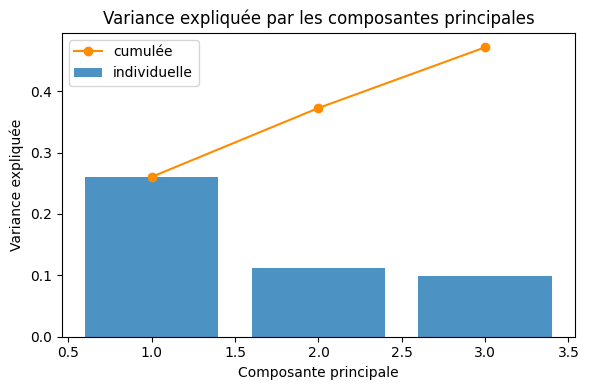

In [19]:
from sklearn.decomposition import PCA

pca_epi = PCA(n_components=3, random_state=42)
X_epi_pca = pca_epi.fit_transform(X_model)

print("Variance expliquée par composante :", pca_epi.explained_variance_ratio_.round(3))
print(f"Variance totale expliquée par les 3 composantes : {pca_epi.explained_variance_ratio_.sum():.1%}")

plt.figure(figsize=(6, 4))
plt.bar(range(1, 4), pca_epi.explained_variance_ratio_, alpha=0.8, label="individuelle")
plt.plot(range(1, 4), np.cumsum(pca_epi.explained_variance_ratio_), marker="o", color="darkorange", label="cumulée")
plt.xlabel("Composante principale")
plt.ylabel("Variance expliquée")
plt.title("Variance expliquée par les composantes principales")
plt.legend()
plt.tight_layout()
plt.show()

## Application de 3 algorithmes de classification non supervisée

### Choix du nombre de clusters (méthode du coude + silhouette)

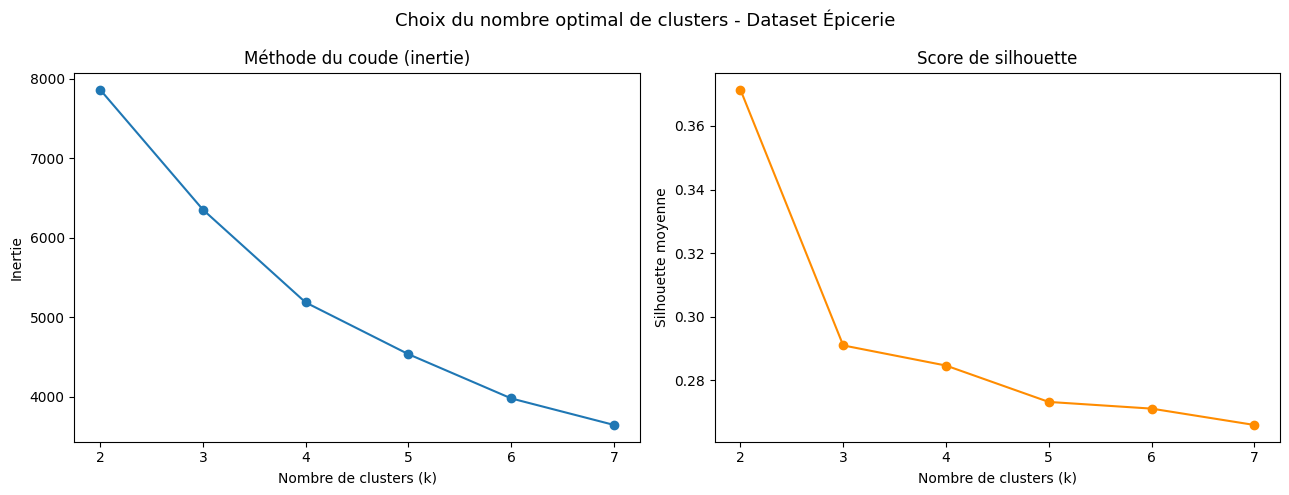

k=2 : inertie=7864.82, silhouette=0.371
k=3 : inertie=6355.92, silhouette=0.291
k=4 : inertie=5188.51, silhouette=0.285
k=5 : inertie=4538.20, silhouette=0.273
k=6 : inertie=3982.26, silhouette=0.271
k=7 : inertie=3648.51, silhouette=0.266


In [20]:
k_range_epi = range(2, 8)
inertias_epi = []
silhouettes_epi = []

for k in k_range_epi:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_epi_pca)
    inertias_epi.append(km.inertia_)
    silhouettes_epi.append(silhouette_score(X_epi_pca, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(k_range_epi), inertias_epi, marker="o")
axes[0].set_title("Méthode du coude (inertie)")
axes[0].set_xlabel("Nombre de clusters (k)")
axes[0].set_ylabel("Inertie")

axes[1].plot(list(k_range_epi), silhouettes_epi, marker="o", color="darkorange")
axes[1].set_title("Score de silhouette")
axes[1].set_xlabel("Nombre de clusters (k)")
axes[1].set_ylabel("Silhouette moyenne")

plt.suptitle("Choix du nombre optimal de clusters - Dataset Épicerie", fontsize=13)
plt.tight_layout()
plt.show()

for k, i, s in zip(k_range_epi, inertias_epi, silhouettes_epi):
    print(f"k={k} : inertie={i:.2f}, silhouette={s:.3f}")

### Algorithme 1 : K-Means

K-Means (k=4) - silhouette : 0.285
Tailles des clusters : [657 499 531 521]


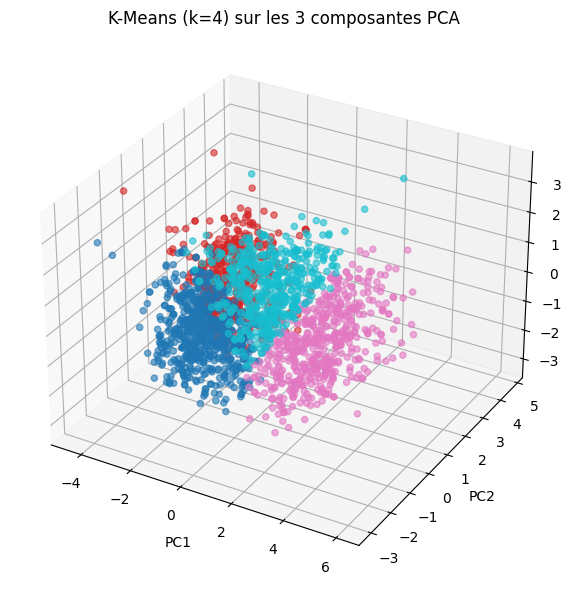

In [21]:
k_opt = 4

kmeans_epi = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
labels_kmeans = kmeans_epi.fit_predict(X_epi_pca)

sil_kmeans = silhouette_score(X_epi_pca, labels_kmeans)
print(f"K-Means (k={k_opt}) - silhouette : {sil_kmeans:.3f}")
print("Tailles des clusters :", np.bincount(labels_kmeans))

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(projection="3d")
scatter = ax.scatter(X_epi_pca[:, 0], X_epi_pca[:, 1], X_epi_pca[:, 2], c=labels_kmeans, cmap="tab10", alpha=0.6, s=20)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title(f"K-Means (k={k_opt}) sur les 3 composantes PCA")
plt.tight_layout()
plt.show()

### Algorithme 2 : Clustering Hiérarchique (Agglomerative Clustering)

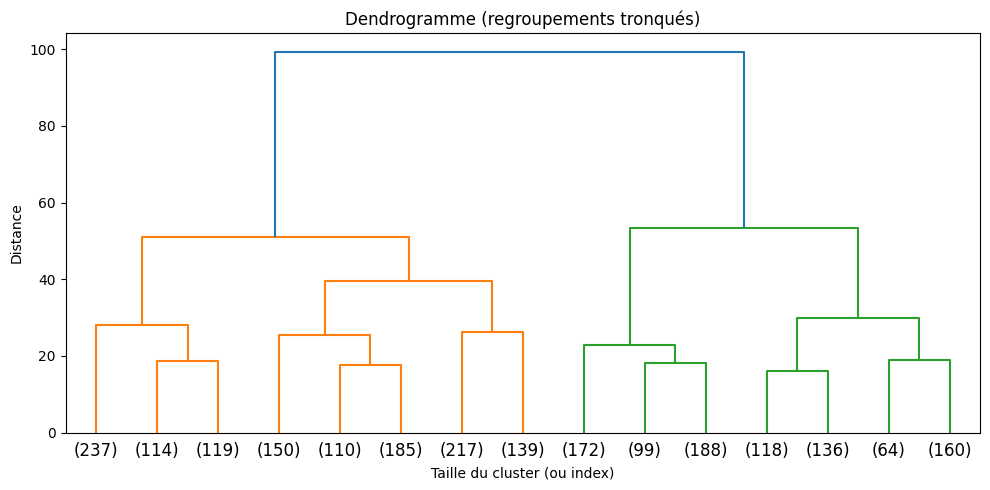

Agglomerative Clustering (k=4) - silhouette : 0.226
Tailles des clusters : [801 478 459 470]


In [22]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Dendrogramme (tronqué aux derniers regroupements, sinon illisible avec >2000 individus)
Z = linkage(X_epi_pca, method="ward")

plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode="lastp", p=15, show_leaf_counts=True)
plt.title("Dendrogramme (regroupements tronqués)")
plt.xlabel("Taille du cluster (ou index)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

agglo_epi = AgglomerativeClustering(n_clusters=k_opt, linkage="ward")
labels_agglo = agglo_epi.fit_predict(X_epi_pca)

sil_agglo = silhouette_score(X_epi_pca, labels_agglo)
print(f"Agglomerative Clustering (k={k_opt}) - silhouette : {sil_agglo:.3f}")
print("Tailles des clusters :", np.bincount(labels_agglo))

### Algorithme 3 : Gaussian Mixture Model (GMM)

In [23]:
from sklearn.mixture import GaussianMixture

gmm_epi = GaussianMixture(n_components=k_opt, random_state=42, n_init=10)
labels_gmm = gmm_epi.fit_predict(X_epi_pca)

sil_gmm = silhouette_score(X_epi_pca, labels_gmm)
print(f"GMM (k={k_opt}) - silhouette : {sil_gmm:.3f}")
print("Tailles des clusters :", np.bincount(labels_gmm))

GMM (k=4) - silhouette : 0.256
Tailles des clusters : [528 593 512 575]


## Comparaison des résultats et évaluation des modèles

              Algorithme  Silhouette
                 K-Means    0.284595
        Gaussian Mixture    0.255809
Agglomerative Clustering    0.225730


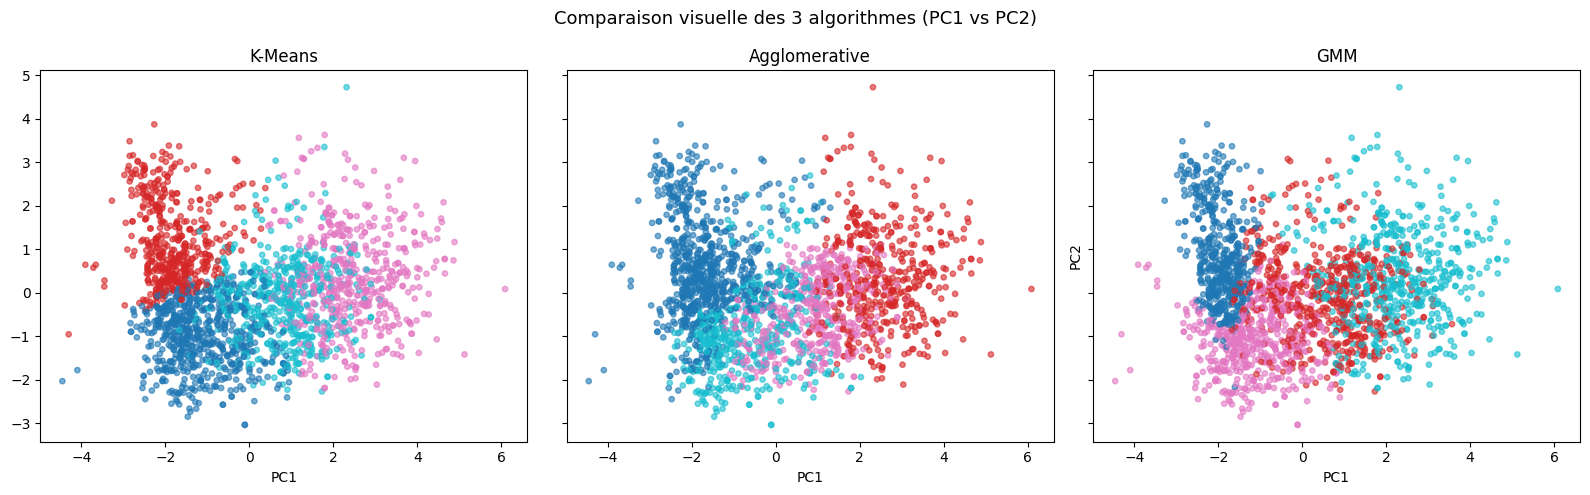


Meilleur algorithme selon le score de silhouette : K-Means


In [24]:
comparison = pd.DataFrame({
    "Algorithme": ["K-Means", "Agglomerative Clustering", "Gaussian Mixture"],
    "Silhouette": [sil_kmeans, sil_agglo, sil_gmm],
}).sort_values("Silhouette", ascending=False)
print(comparison.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)
for ax, (name, labels) in zip(axes, [("K-Means", labels_kmeans), ("Agglomerative", labels_agglo), ("GMM", labels_gmm)]):
    ax.scatter(X_epi_pca[:, 0], X_epi_pca[:, 1], c=labels, cmap="tab10", alpha=0.6, s=15)
    ax.set_title(name)
    ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.suptitle("Comparaison visuelle des 3 algorithmes (PC1 vs PC2)", fontsize=13)
plt.tight_layout()
plt.show()

best_algo = comparison.iloc[0]["Algorithme"]
print(f"\nMeilleur algorithme selon le score de silhouette : {best_algo}")

## Profiling des clusters (caractérisation des groupes de clients)

Taille des clusters :
Cluster
0    657
1    499
2    531
3    521
Name: count, dtype: int64

Profil moyen par cluster :
          Income   Age  Total_Spending  Total_Purchases  Children  \
Cluster                                                             
0        41883.3  47.8           158.5              9.7       1.4   
1        30231.1  37.0           120.0              8.3       1.0   
2        77800.6  45.3          1336.7             20.4       0.2   
3        59072.0  49.3           894.9             22.1       1.1   

         Customer_For  Total_AcceptedCmp  Recency  NumWebVisitsMonth  
Cluster                                                               
0               243.2                0.1     48.9                5.8  
1               396.9                0.2     49.6                7.1  
2               300.4                1.0     49.1                2.4  
3               509.3                0.5     48.7                6.0  


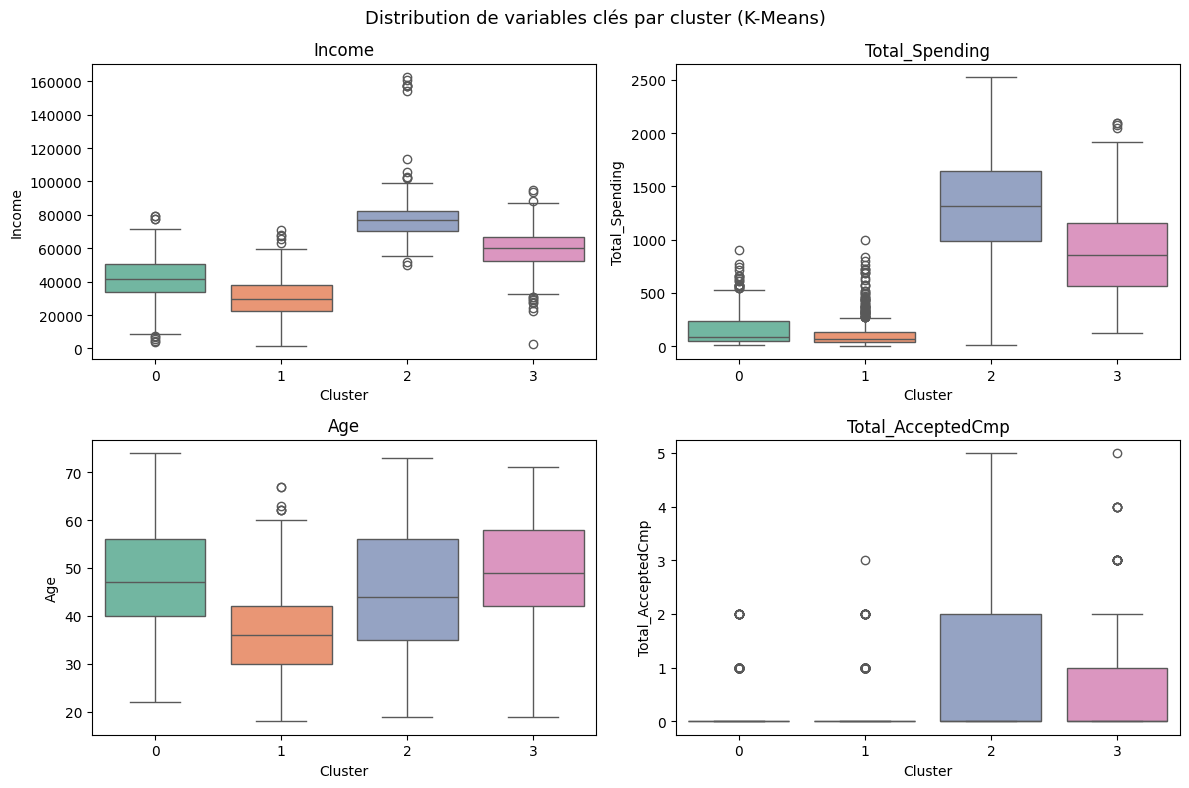

In [25]:
labels_map = {"K-Means": labels_kmeans, "Agglomerative Clustering": labels_agglo, "Gaussian Mixture": labels_gmm}
db_epi["Cluster"] = labels_map[best_algo]

print("Taille des clusters :")
print(db_epi["Cluster"].value_counts().sort_index())

profile_cols = ["Income", "Age", "Total_Spending", "Total_Purchases", "Children",
                 "Customer_For", "Total_AcceptedCmp", "Recency", "NumWebVisitsMonth"]
profile = db_epi.groupby("Cluster")[profile_cols].mean().round(1)
print("\nProfil moyen par cluster :")
print(profile)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for ax, col in zip(axes, ["Income", "Total_Spending", "Age", "Total_AcceptedCmp"]):
    sns.boxplot(ax=ax, x="Cluster", y=col, hue="Cluster", data=db_epi, palette="Set2", legend=False)
    ax.set_title(col)
plt.suptitle(f"Distribution de variables clés par cluster ({best_algo})", fontsize=13)
plt.tight_layout()
plt.show()

### Interprétation des profils

En croisant les moyennes par cluster (K-Means, k=4, meilleur score de silhouette), on distingue 4 profils de clients bien différenciés :

- **Cluster 2 — Clients premium (~531 clients)** : revenu moyen le plus élevé (~77 800), dépenses totales très supérieures aux autres groupes (~1 337), très peu d'enfants au foyer, et le meilleur taux d'acceptation des campagnes marketing (~1.0 campagne acceptée en moyenne). Ce sont les clients à plus forte valeur, prioritaires pour les offres premium.
- **Cluster 3 — Clients fidèles à forte fréquence d'achat (~521 clients)** : revenu confortable (~59 000), dépenses élevées (~895), le plus grand nombre d'achats total (~22) et l'ancienneté la plus longue (~509 jours). Un segment stable et engagé, à fidéliser.
- **Cluster 0 — Familles à budget modéré (~657 clients)** : revenu moyen (~41 900), le plus d'enfants au foyer (~1.4), mais des dépenses et une fréquence d'achat limitées (~159, ~10 achats). Cible potentielle pour des offres familiales ou des promotions.
- **Cluster 1 — Jeunes clients à faible pouvoir d'achat (~499 clients)** : revenu le plus faible (~30 200), clients les plus jeunes (~37 ans), dépenses les plus faibles, mais le plus de visites web par mois : un segment récent (ancienneté la plus courte) et digital-first, à convertir progressivement vers plus de dépenses.

## Conclusion

Contrairement au dataset Iris (données propres, 3 classes bien connues, silhouette jusqu'à 0.58), le dataset Épicerie est un cas réel de segmentation client : il n'y a pas de vraie étiquette à retrouver, les variables sont bruitées et mélangent quantitatif et catégoriel, ce qui se traduit par des scores de silhouette nettement plus modestes (~0.2-0.3) pour les 3 algorithmes testés. K-Means est celui qui a le mieux performé sur les composantes PCA, suivi de l'Agglomerative Clustering puis du GMM (les clusters gaussiens se chevauchent davantage sur ces données).

La réduction de dimension (sélection de features pour éliminer les variables redondantes, puis PCA à 3 composantes conservant ~47% de la variance) a permis de simplifier le problème et de visualiser des clusters plus interprétables qu'en travaillant sur les 13 variables brutes.

Le profiling fait ressortir 4 segments clients actionnables : des clients **premium** à forte valeur et forte réceptivité aux campagnes, des clients **fidèles** à fréquence d'achat élevée, des **familles** à budget modéré, et des **jeunes clients digital-first** à faible pouvoir d'achat mais fort potentiel de conversion.

Pistes d'amélioration : tester d'autres nombres de composantes PCA ou une MFA pour mieux traiter le mélange quantitatif/catégoriel, essayer DBSCAN pour détecter des clients atypiques (outliers), ou pondérer les variables selon leur pertinence métier (ex. revenu et dépenses) avant clustering.